# Tusked Elephants

The illegal ivory trade in the 1970s and 80s was so severe that some elephant populations declined by 50-90%, with poachers targeting animals with the largest tusks. Safeguard measures implemented in 1990 led to a period of population recovery. What impact did the poaching period have on the genetic trait for tusk size?

In this project we will analyze tusk size data for elephants born before the poaching period compared to elephants born after the recovery period began.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('male-elephant-tusk-size.csv')
df 

,period,elephant_id,age,shoulder_height,tusk_length
0,1966-68,58,2.5,149.0,30.0
1,1966-68,78,2.5,151.0,27.0
2,1966-68,86,2.5,127.0,27.0
3,1966-68,293,2.5,156.0,32.0
4,1966-68,29,3.0,146.0,28.5
...,...,...,...,...,...
294,2005-13,78,7.5,220.0,84.7
295,2005-13,144,7.5,220.0,58.9
296,2005-13,1,9.0,220.0,99.0
297,2005-13,48,9.0,230.0,105.4


Note that the `shoulder_height` column is measured in centimeters, as is `tusk_length`.
Let's explore whether tusk length changed across the two time periods.

### Comparing Tusk Length

To help us compare, let's split the data into two dataframes based on the time period.


In [3]:
pre_poaching = df.query('period == "1966-68"')
pre_poaching.head(3)

,period,elephant_id,age,shoulder_height,tusk_length
0,1966-68,58,2.5,149.0,30.0
1,1966-68,78,2.5,151.0,27.0
2,1966-68,86,2.5,127.0,27.0


In [4]:
post_recovery = df.query('period == "2005-13"')
post_recovery.head(3)

,period,elephant_id,age,shoulder_height,tusk_length
214,2005-13,52,4.5,195.0,47.0770
215,2005-13,14,5.0,200.0,48.2328
216,2005-13,42,5.0,180.0,54.0118


Now we can compare the average tusk length for the two periods.


In [5]:
print("Before:", pre_poaching['tusk_length'].mean())
print("After:", post_recovery['tusk_length'].mean())

Before: 67.44088785046729
After: 57.968809411764695


On average, tusk lengths appear to have decreased after the poaching period. However, these simple averages do not account for the confounding factor of age. How could age possibly skew the data?

Younger elephants are generally smaller and have shorter tusks. If the average age of the elephants in the second cohort is younger, that could skew the data toward smaller tusks. We can address this by analyzing the relationships between tusk length and the overall body height.

### Tusk Length vs Shoulder Height
Let's start by creating a scatter plot of tusk length vs shoulder height for the two time periods.


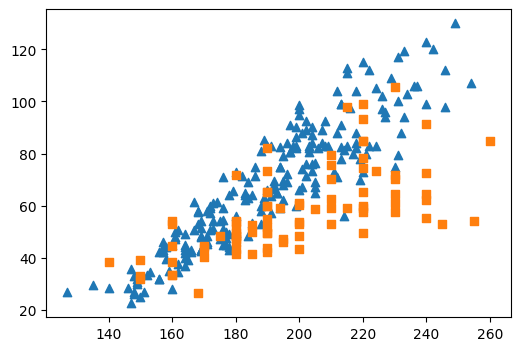

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(pre_poaching['shoulder_height'], pre_poaching['tusk_length'], marker='^')
plt.scatter(post_recovery['shoulder_height'], post_recovery['tusk_length'], marker='s')
plt.show()

Now let's format the plot to make it easier to interpret. We will label the axes and mark the two groups directly on the plot.


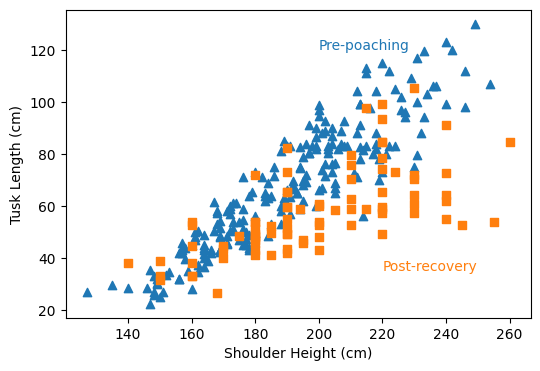

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(pre_poaching['shoulder_height'], pre_poaching['tusk_length'], marker='^')
plt.scatter(post_recovery['shoulder_height'], post_recovery['tusk_length'], marker='s')
plt.xlabel('Shoulder Height (cm)')
plt.ylabel('Tusk Length (cm)')
plt.text(x=200, y=120, s='Pre-poaching', color='C0')
plt.text(x=220, y=35, s='Post-recovery', color='C1')
plt.show()

For the same shoulder height, pre-poaching elephants generally have longer tusks.

### Modeling Tusk Length
How can we quantify the change in the relationship between the two periods? One approach is to create linear models for each period and then compare the slopes.

A linear model fits a straight line through the data, allowing us to make predictions.

In [8]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

class LinearModel:
    def __init__(self, model_name=""):
        self.model_name = model_name
        
    def fit(self, x, y):
        x = pd.DataFrame(x)
        linear_model = LinearRegression().fit(x, y)
        y_pred = linear_model.predict(x)
        self.slope = linear_model.coef_[0]
        self.intercept = linear_model.intercept_
        self.rsquared = r2_score(y, y_pred)
        
    def predict(self, x):
        return self.slope * x + self.intercept

    def plot_model(self, x_min, x_max, color="black"):
        y_min = self.predict(x_min)
        y_max = self.predict(x_max)
        plt.plot([x_min, x_max], [y_min, y_max], color=color)
        
    def print_model_info(self):
        m = self.slope
        b = self.intercept
        rsquared = self.rsquared
        model_name = self.model_name
        print(f'LinearModel({model_name}):')
        print(f'Parameters: slope = {m:.2f}, intercept = {b:.2f}')
        print(f'Equation: y = {m:.2f}x + {b:.2f}')
        print(f'Goodness of Fit (R²): {rsquared:.3f}')

In [9]:
pre_model = LinearModel("pre_poaching")
pre_model.fit(x=pre_poaching['shoulder_height'], y=pre_poaching['tusk_length'])

In [10]:
post_model = LinearModel("post_recovery")
post_model.fit(x=post_recovery['shoulder_height'], y=post_recovery['tusk_length'])

Now that we have the two models, let's visualize them together.

### Plotting the models
Earlier we plotted the two scatter plots.

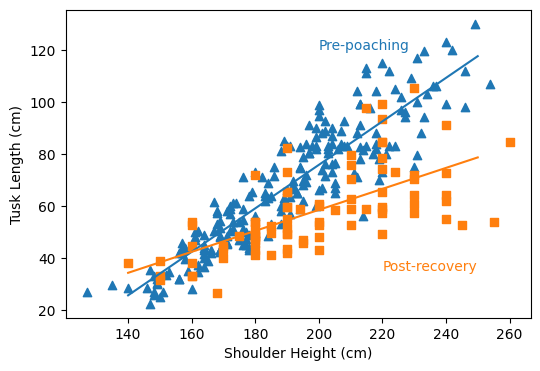

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(pre_poaching['shoulder_height'], pre_poaching['tusk_length'], marker='^')
plt.scatter(post_recovery['shoulder_height'], post_recovery['tusk_length'], marker='s')
plt.xlabel('Shoulder Height (cm)')
plt.ylabel('Tusk Length (cm)')
plt.text(200, 120, 'Pre-poaching', color='C0')
plt.text(220, 35, 'Post-recovery', color='C1')
pre_model.plot_model(140, 250, 'C0')
post_model.plot_model(140, 250, 'C1')


Looking at the two models, we see that the slope for both is positive, indicating that as elephant height increases, tusk length also increases.

Comparing the slopes of the two models, we find that the post_recovery model is shallower than the pre_poaching model.That suggests that poaching placed evolutionary pressure on tusk length, leading to elephants with shorter tusks. Let's print the equations for the two models to give us more precise insights into this relationship.


In [12]:
pre_model.print_model_info()

LinearModel(pre_poaching):
Parameters: slope = 0.83, intercept = -91.14
Equation: y = 0.83x + -91.14
Goodness of Fit (R²): 0.831


In [13]:
post_model.print_model_info()

LinearModel(post_recovery):
Parameters: slope = 0.40, intercept = -22.02
Equation: y = 0.40x + -22.02
Goodness of Fit (R²): 0.431


Here, we observe that the slope prior to poaching is 0.83. After the extreme poaching event, the slope becomes shallower, at 0.40.

The targeted poaching of elephants with the longest tusks seems to have reduced the tusk length for future generations.

## Project extensions


### Extension 1: Percent Difference Analysis
Use the two models to predict tusk length at a shoulder height of 250 cm, then compare the two predictions as a percent difference.

In [14]:
height = 250
pre_tusk_250 = pre_model.predict(height)
post_tusk_250 = post_model.predict(height)
pct_diff_250 = (pre_tusk_250 - post_tusk_250) / post_tusk_250 * 100

print(f"Predicted pre-poaching tusk length at {height} cm: {pre_tusk_250:.2f} cm")
print(f"Predicted post-recovery tusk length at {height} cm: {post_tusk_250:.2f} cm")
print(f"Pre-poaching tusks are {pct_diff_250:.1f}% longer than post-recovery tusks at this height")

Predicted pre-poaching tusk length at 250 cm: 117.55 cm
Predicted post-recovery tusk length at 250 cm: 78.67 cm
Pre-poaching tusks are 49.4% longer than post-recovery tusks at this height


At a shoulder height of 250 cm, pre-poaching elephants are predicted to have tusks roughly 49% longer than post-recovery elephants of the same size. This is a substantial difference, and it holds even after controlling for body size — reinforcing that this isn't just younger/smaller elephants dragging the post-recovery average down, but a genuine shift in the tusk-length-to-body-size relationship.

### Extension 2: Taller Elephants
Elephants can reach shoulder heights of up to 400 cm. Use the models to predict tusk length at that height for both cohorts.

In [15]:
height = 400
pre_tusk_400 = pre_model.predict(height)
post_tusk_400 = post_model.predict(height)
pct_diff_400 = (pre_tusk_400 - post_tusk_400) / post_tusk_400 * 100

print(f"Predicted pre-poaching tusk length at {height} cm: {pre_tusk_400:.2f} cm")
print(f"Predicted post-recovery tusk length at {height} cm: {post_tusk_400:.2f} cm")
print(f"Pre-poaching tusks are {pct_diff_400:.1f}% longer than post-recovery tusks at this height")

print()
print("Shoulder height range in our data:", df['shoulder_height'].min(), "-", df['shoulder_height'].max(), "cm")

Predicted pre-poaching tusk length at 400 cm: 242.76 cm
Predicted post-recovery tusk length at 400 cm: 139.08 cm
Pre-poaching tusks are 74.5% longer than post-recovery tusks at this height

Shoulder height range in our data: 127.0 - 260.0 cm


At 400 cm, the gap widens even further to roughly a 75% difference. However, this prediction should be treated with caution: our tallest recorded elephant is only 260 cm, so 400 cm is a large extrapolation well outside the range of observed data. Linear models can behave unpredictably outside their training range, and the post-recovery model already has a noticeably weaker fit (R² = 0.431) than the pre-poaching model (R² = 0.831), meaning it's a less reliable line to extrapolate from in the first place. The 400 cm prediction is best read as illustrating the widening trend rather than as a precise, trustworthy estimate.